In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.datasets import load_iris
iris_data = load_iris()

type(iris_data)

sklearn.utils._bunch.Bunch

In [5]:
iris_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
iris_data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris_data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris_data['data']

In [9]:
iris_df = pd.DataFrame(data = iris_data['data'], columns = iris_data['feature_names'])
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
iris_df['Iris type'] = iris_data['target']
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Iris type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


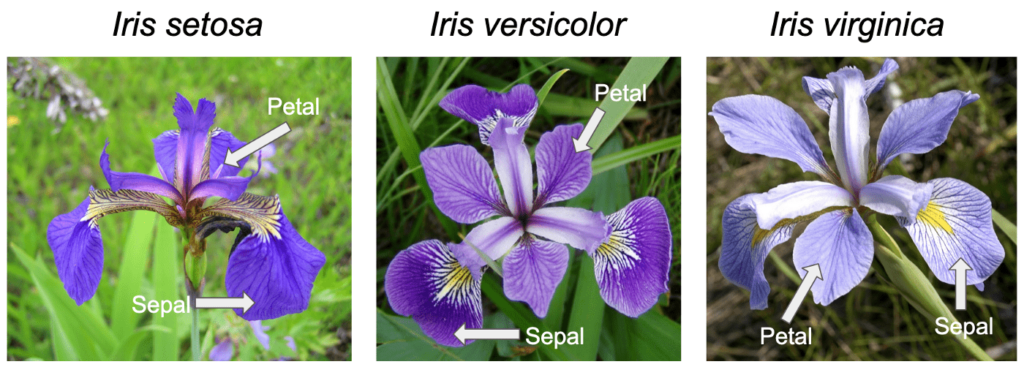

In [12]:
from PIL import Image
img = Image.open(r"iris.png")
img

In [13]:
df = pd.read_csv(r"Iris_Data.csv")
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
print(f"Dataset shape: {iris.shape}")

iris.info()

Dataset shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [17]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [18]:
print("\nMissing values per column: ")
print(iris.isnull().sum())


Missing values per column: 
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [19]:
dup = df.duplicated().sum()
print(f"Number of duplicated rows are {dup}")

Number of duplicated rows are 1


In [20]:
df.Species.value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

unique_species = df['Species'].unique()

print("Encoded Species Values: ")
print(unique_species)

Encoded Species Values: 
[0 1 2]


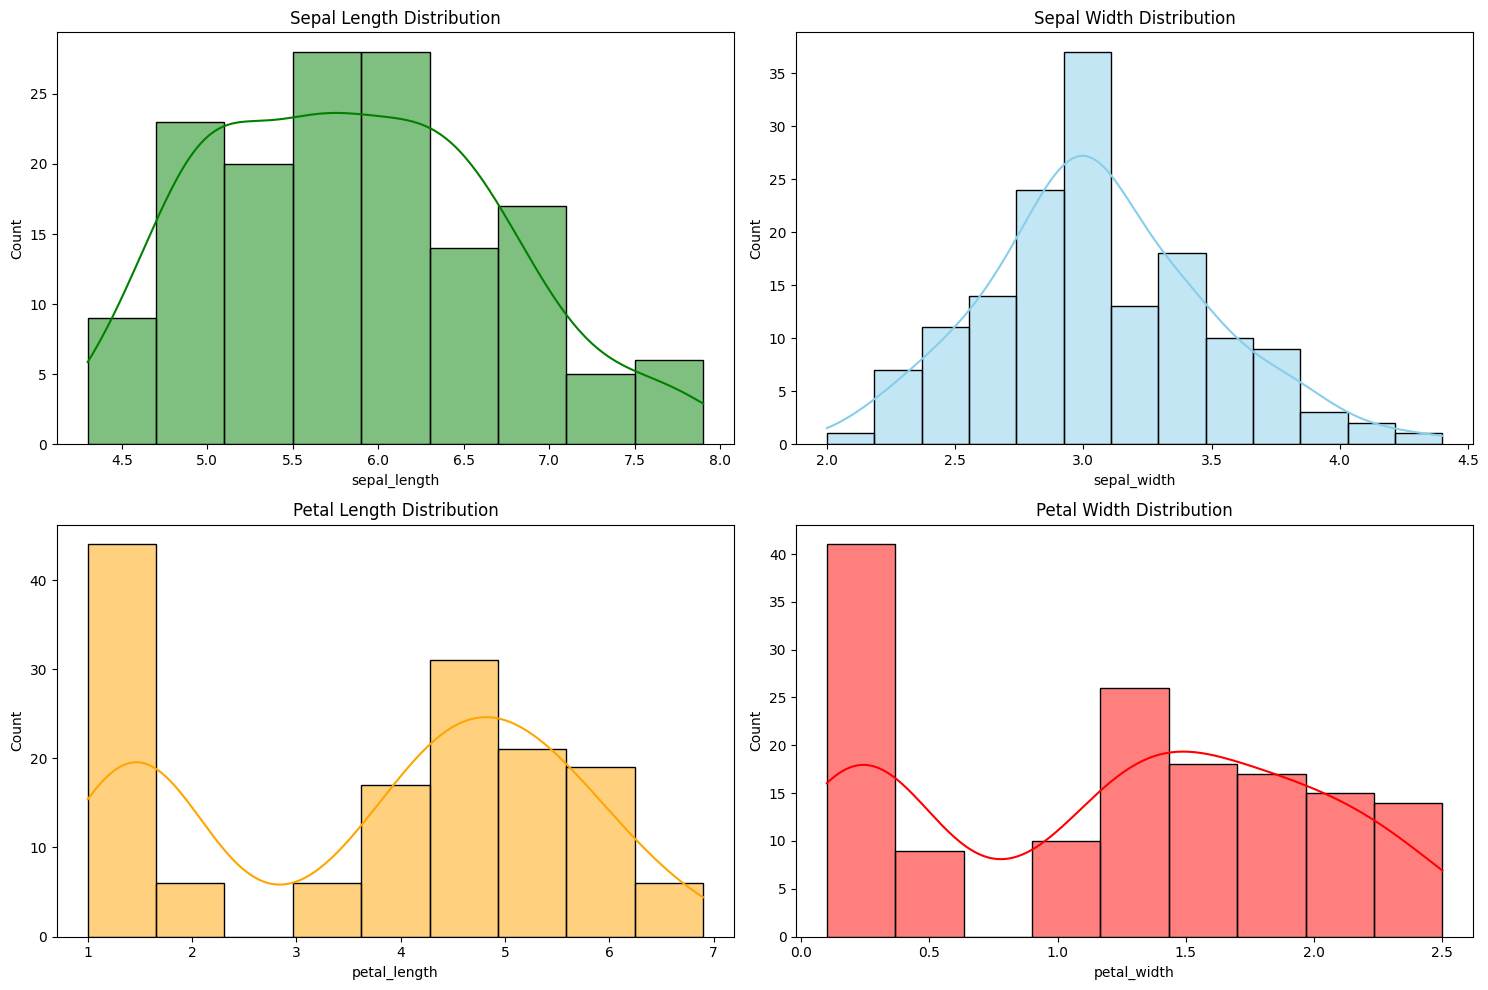

In [24]:
fig, axes, = plt.subplots(2,2, figsize=(15,10))
sns.histplot(iris['sepal_length'], kde=True, ax=axes[0,0], color='green')
axes[0, 0].set_title('Sepal Length Distribution')
sns.histplot(iris['sepal_width'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Sepal Width Distribution')
sns.histplot(iris['petal_length'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Petal Length Distribution')
sns.histplot(iris['petal_width'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Petal Width Distribution')
plt.tight_layout()
plt.show()

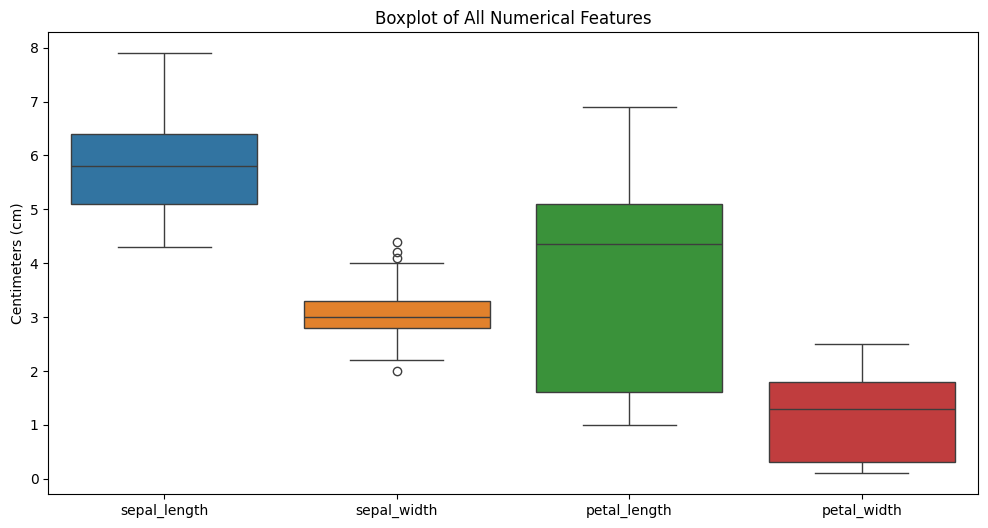

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=iris.drop('species', axis=1))
plt.title('Boxplot of All Numerical Features')
plt.ylabel('Centimeters (cm)')
plt.show()

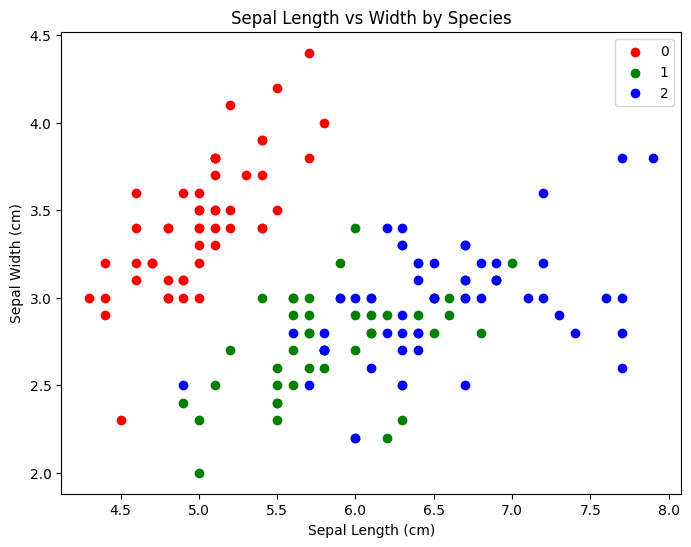

In [27]:
plt.figure(figsize=(8, 6))
species = df['Species'].unique()
colors = ['red', 'green', 'blue']
for i in range(len(species)):
    x = df[df['Species'] == species[i]]
    plt.scatter(x['Sepal.Length'], x['Sepal.Width'], c=colors[i], label=species[i])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Width by Species')
plt.legend()
plt.show()

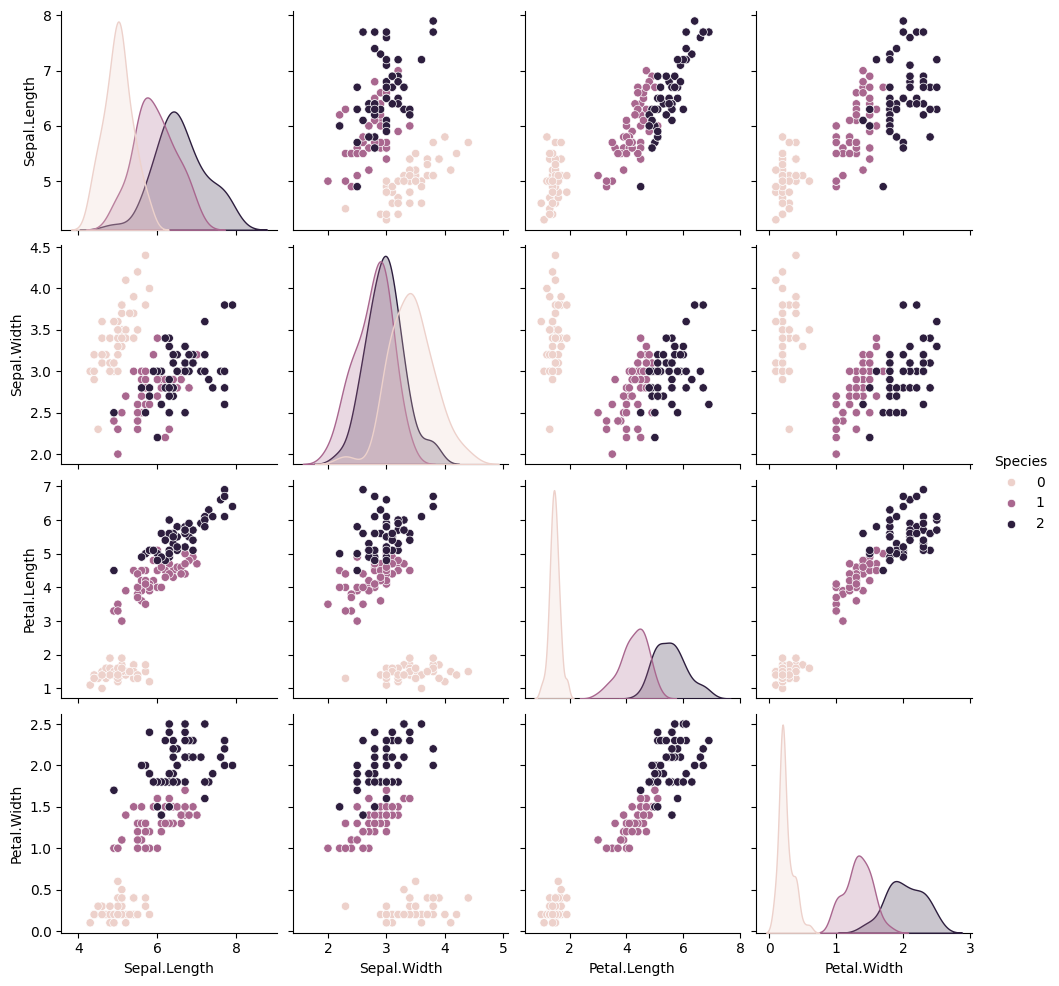

In [28]:
sns.pairplot(df , hue='Species');

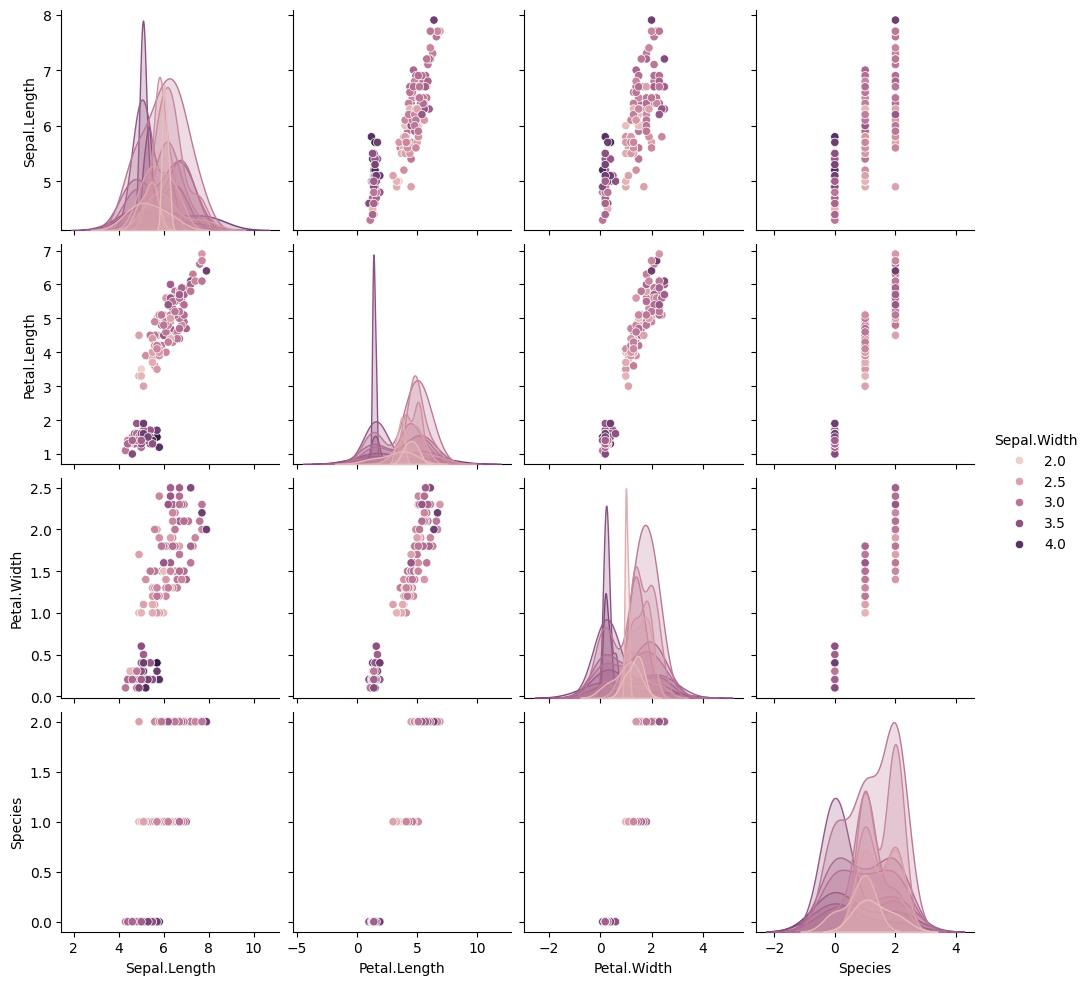

In [29]:
sns.pairplot(df , hue='Sepal.Width');

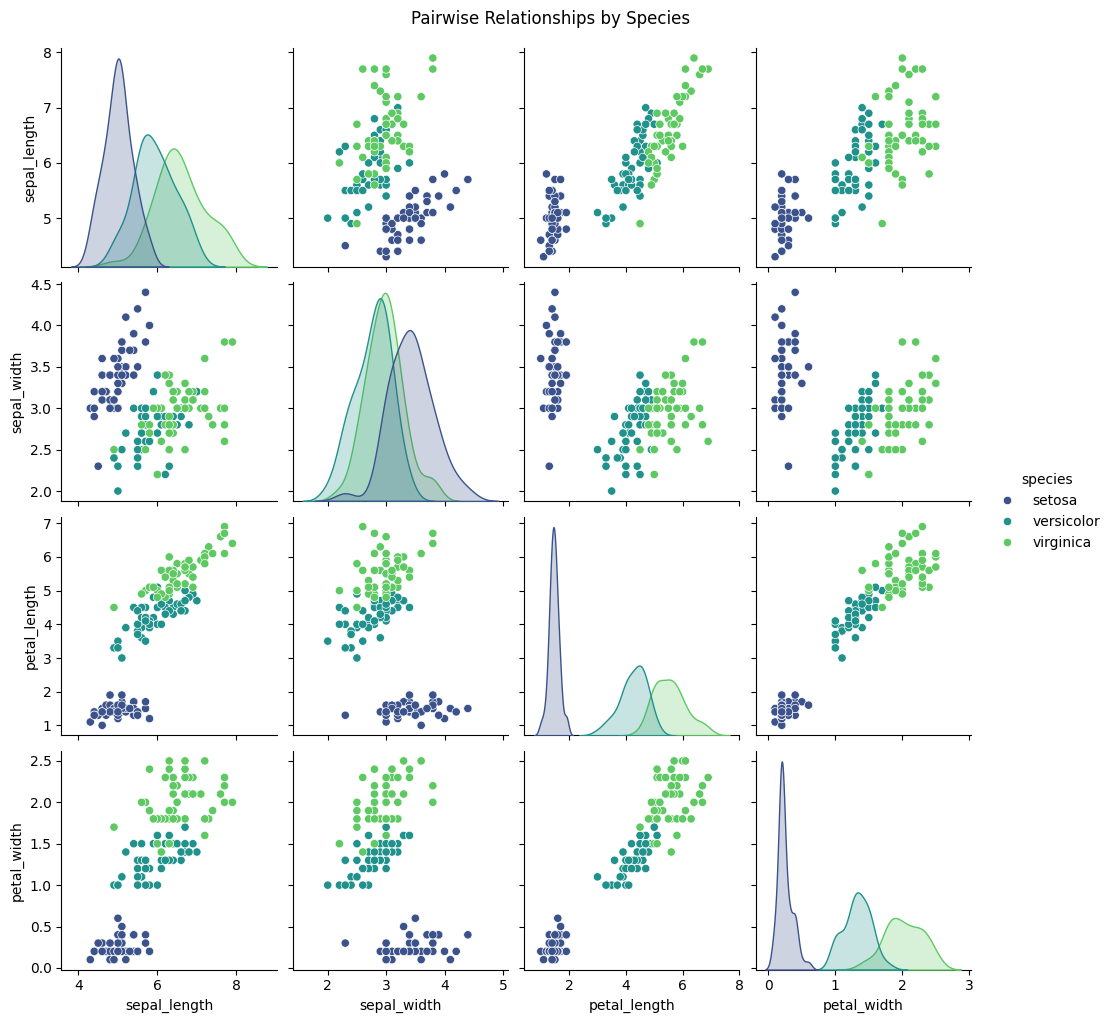

In [30]:
sns.pairplot(iris, hue='species', palette='viridis', height=2.5)
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.show()

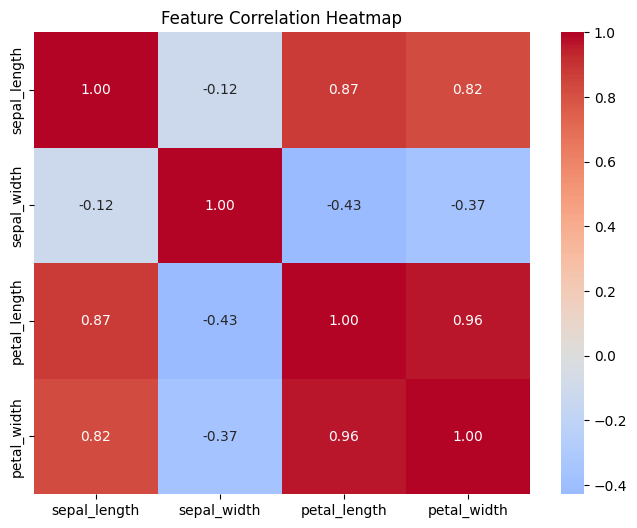

In [31]:
corr = iris.drop('species', axis=1).corr()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [32]:
df.iloc[:, :-1].corr().style.background_gradient(cmap='coolwarm').format(precision=2)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.00,-0.12,0.87,0.82
Sepal.Width,-0.12,1.00,-0.43,-0.37
Petal.Length,0.87,-0.43,1.00,0.96
Petal.Width,0.82,-0.37,0.96,1.00


C:\Users\ARUN\AppData\Local\Temp\ipykernel_22792\348396784.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='sepal_length', data=iris, ax=axes[0, 0], palette='Set2')
C:\Users\ARUN\AppData\Local\Temp\ipykernel_22792\348396784.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='sepal_width', data=iris, ax=axes[0, 1], palette='Set2')
C:\Users\ARUN\AppData\Local\Temp\ipykernel_22792\348396784.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_length', data=iris, ax=axes[1, 0], palette='Set

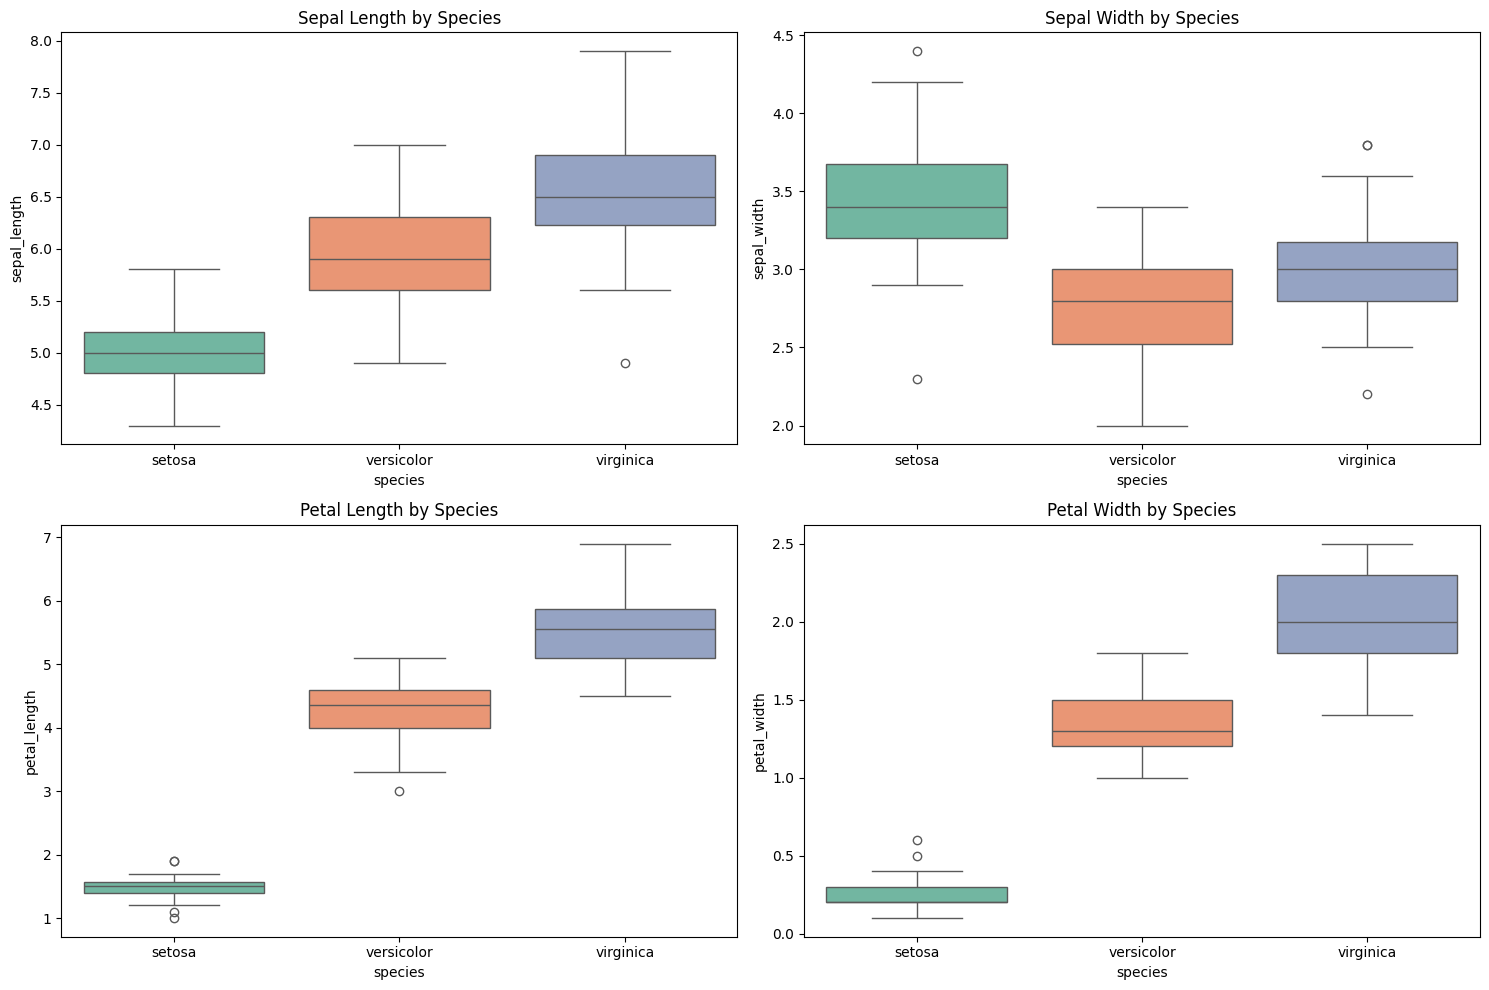

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Plot distributions by species
sns.boxplot(x='species', y='sepal_length', data=iris, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Sepal Length by Species')
sns.boxplot(x='species', y='sepal_width', data=iris, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Sepal Width by Species')
sns.boxplot(x='species', y='petal_length', data=iris, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Petal Length by Species')
sns.boxplot(x='species', y='petal_width', data=iris, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Petal Width by Species')
plt.tight_layout()
plt.show()

In [2]:
%%writefile .gitignore

.ipynb_checkpoints/
__pycache__/
venv/
Doc/

Overwriting .gitignore
